# Convolution of discrete functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt

import sympy as sp
from sympy import Symbol, oo, integrate 
from sympy import lambdify, Symbol, integrate
print("Running Sympy:",sp.__version__)
ts = Symbol('t')

from ipywidgets import interactive
from IPython.display import HTML

from lcapy import Circuit, j, omega, s, exp, t, u, delta
from lcapy import R, C, L

def H(t):
    return np.heaviside(t, 1)

Running Sympy: 1.13.3


/Users/jonathanhow/Jon/venv312/lib/python3.12/site-packages/lcapy/__init__.py:76: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


##  Example 6

In [4]:
def Ud(nn):  # discrete unit step
    nn = np.asarray(nn)
    return (nn >= 0).astype(float)

In [5]:
# discrete indices
n = np.arange(-10,10)
k = n

# define the 2 functions to convolve
g = Ud(n)
w = 2.0**n*Ud(-n)

# compute the discrete convolution
y = []
for nn in n:
    y = np.append(y,np.sum(w*Ud(nn-k)))

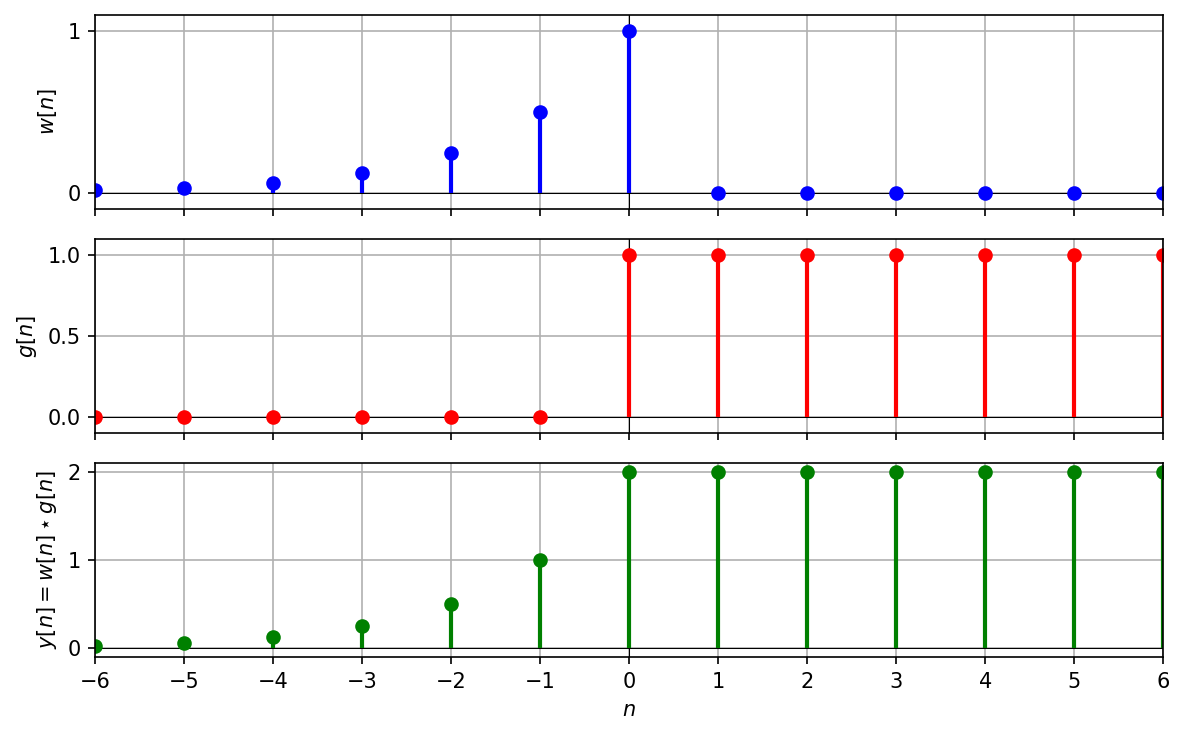

In [6]:
fig = plt.figure(figsize=(8, 5),dpi=150)
ax1 = fig.add_subplot(311)
ax1.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax1.plot([0,0],[-2, 2],'k-',lw=0.5)
ax2 = fig.add_subplot(312, sharex=ax1)
ax2.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax2.plot([0,0],[-2, 2],'k-',lw=0.5)
ax3 = fig.add_subplot(313, sharex=ax1)
ax3.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax3.plot([0,0],[-2, 2],'k-',lw=0.5)

major_ticks = k    
ax1.set_xticks(major_ticks)
ax1.set_yticks(np.arange(0,2))
ax1.grid(True)

markerline, stemlines, baseline = ax1.stem(k, w,linefmt='b',markerfmt='bo')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax2.stem(k, g,linefmt='r',markerfmt='ro',label='$a = $')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax3.stem(k, y,linefmt='g',markerfmt='go',label='$a = $')
plt.setp(baseline, visible=False)

ax1.set_xlim([-6, 6])
ax1.set_ylim([-0.1, 1.1])
ax2.set_ylim([-0.1, 1.1])
ax3.set_ylim([-0.1, 2.1])
ax1.set_ylabel('$w[n]$')
ax2.set_ylabel('$g[n]$')
ax3.set_ylabel('$y[n]=w[n]\star g[n]$')
ax3.set_xlabel('$n$')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.savefig('figs/Topic5_ex6.pdf',format='pdf',dpi=300)
plt.show()

##  Example 7

In [7]:
n = np.arange(-4,10)
k = n

def g(nn):
    nn = np.asarray(nn)
    vals = {
        -2: -2,
        -1:  4,
         0:  2,
         2: -3,
         4:  3,
         5:  1,
    }
    out = np.zeros(nn.shape, dtype=int)
    for k, v in vals.items():
        out[nn == k] = v
    return out

def w(nn):
    nn = np.asarray(nn)
    vals = {
        -1: -2,
         0:  3,
    }
    out = np.zeros(nn.shape, dtype=int)
    for k, v in vals.items():
        out[nn == k] = v
    return out

y = []
for nn in n:
    y = np.append(y,np.sum(w(k)*g(nn-k)))

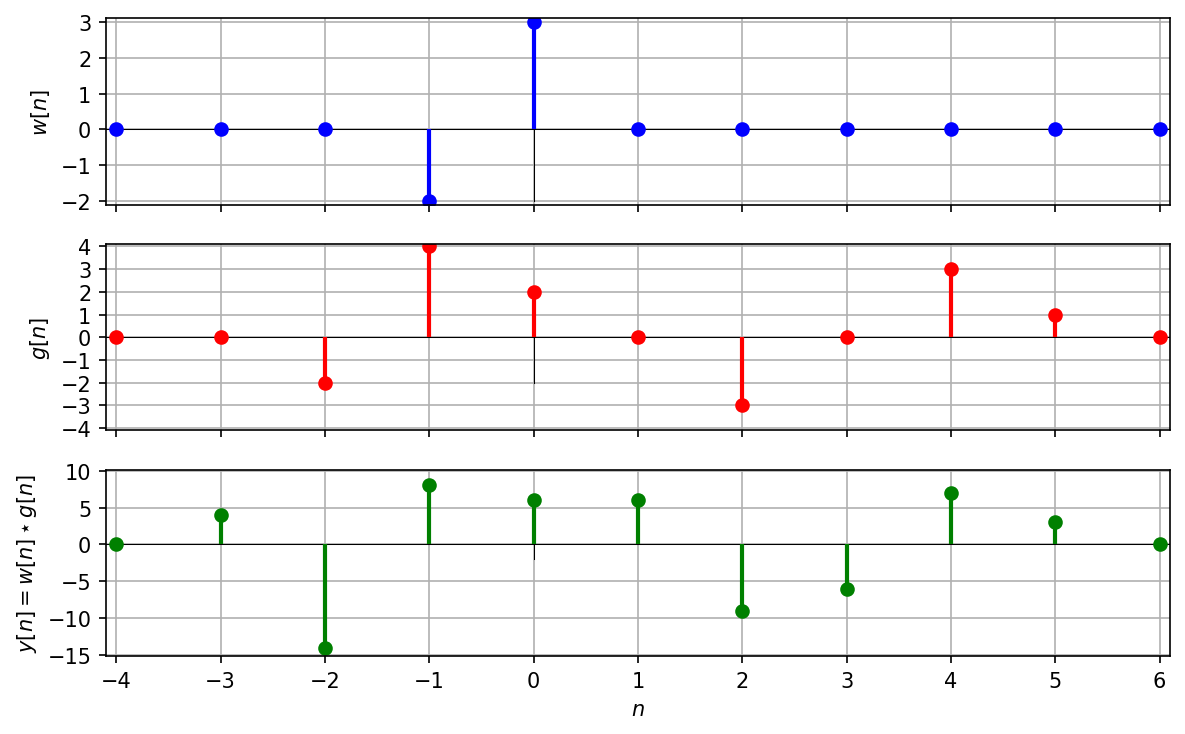

In [8]:
fig = plt.figure(figsize=(8, 5),dpi=150)
ax1 = fig.add_subplot(311)
ax1.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax1.plot([0,0],[-2, 2],'k-',lw=0.5)
ax2 = fig.add_subplot(312, sharex=ax1)
ax2.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax2.plot([0,0],[-2, 2],'k-',lw=0.5)
ax3 = fig.add_subplot(313, sharex=ax1)
ax3.plot([k[0]-1, k[-1]+1],[0,0],'k-',lw=0.5)
ax3.plot([0,0],[-2, 2],'k-',lw=0.5)

major_ticks = k    
ax1.set_xticks(major_ticks)
ax1.set_yticks(np.arange(-15,15))
ax2.set_yticks(np.arange(-15,15))
ax3.set_yticks(np.arange(-15,15,5))
ax1.grid(True)

markerline, stemlines, baseline = ax1.stem(k, w(k),linefmt='b',markerfmt='bo')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax2.stem(k, g(k),linefmt='r',markerfmt='ro',label='$a = $')
plt.setp(baseline, visible=False)
markerline, stemlines, baseline = ax3.stem(k, y,linefmt='g',markerfmt='go',label='$a = $')
plt.setp(baseline, visible=False)

ax1.set_xlim(-4-0.1, 6+0.1)
ax1.set_ylim([-2.1, 3.1])
ax2.set_ylim([-4.1, 4.1])
ax3.set_ylim([-15.1, 10.1])
ax1.set_ylabel('$w[n]$')
ax2.set_ylabel('$g[n]$')
ax3.set_ylabel('$y[n]=w[n]\star g[n]$')
ax3.set_xlabel('$n$')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)
plt.savefig('figs/Topic5_ex7.pdf',format='pdf',dpi=300)
plt.show()

In [9]:
import pandas as pd
table = []
table.append(n)
table.append(w(n))
table.append(g(n))
table.append(y)
df = pd.DataFrame({
    'n': n,
    'w': w(n),
    'g': g(n),
    'y': y,
}).fillna(0)

print(df.to_string(index=False))


 n  w  g     y
-4  0  0   0.0
-3  0  0   4.0
-2  0 -2 -14.0
-1 -2  4   8.0
 0  3  2   6.0
 1  0  0   6.0
 2  0 -3  -9.0
 3  0  0  -6.0
 4  0  3   7.0
 5  0  1   3.0
 6  0  0   0.0
 7  0  0   0.0
 8  0  0   0.0
 9  0  0   0.0


##  Example 8

In [10]:
n = np.arange(-5, 10)
k = np.arange(0, n[-1] + 1)   # summation index

def g(nn):
    nn = np.asarray(nn)
    return (0.5**nn) * Ud(nn)

def w(nn):
    nn = np.asarray(nn)
    return (0.25**nn) * Ud(nn)

y = np.array([
    np.sum(w(k) * g(nn - k))
    for nn in n
])

y2 = np.array([
    np.sum(g(k) * w(nn - k))
    for nn in n
])

print('Computation difference:',np.sum(y-y2))

Computation difference: 0.0


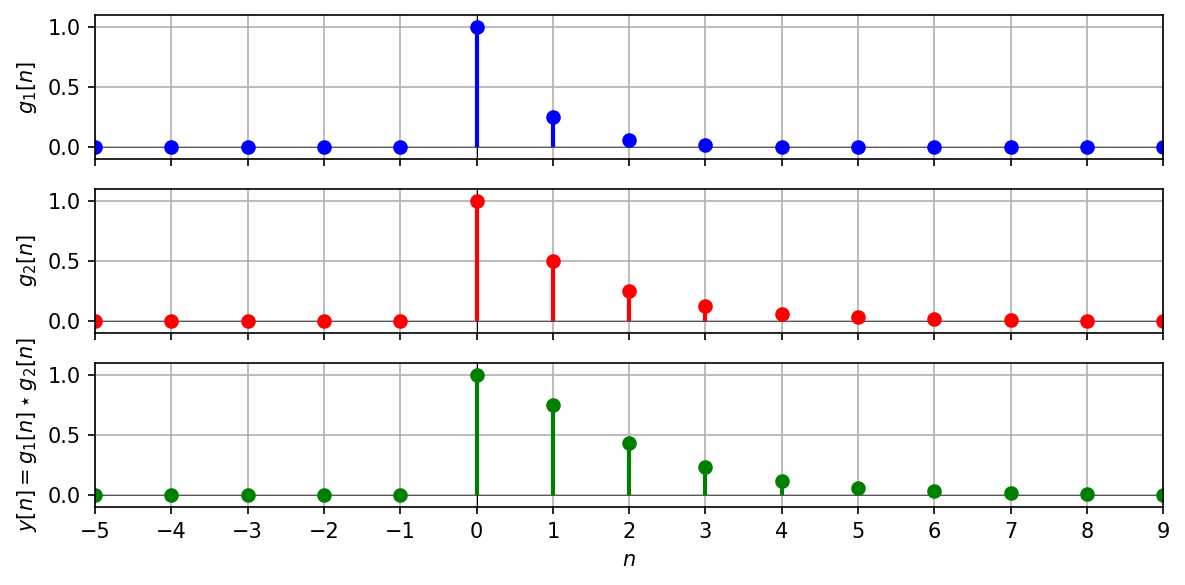

In [11]:
fig = plt.figure(figsize=(8, 4), dpi=150)
ax1 = fig.add_subplot(311)
ax2 = fig.add_subplot(312, sharex=ax1)
ax3 = fig.add_subplot(313, sharex=ax1)

for ax in [ax1, ax2, ax3]:
    ax.plot([n[0]-1, n[-1]+1], [0, 0], 'k-', lw=0.25)
    ax.plot([0, 0], [-2, 2], 'k-', lw=0.5)
    ax.set_xticks(n)
    ax.grid(True)

markerline, stemlines, baseline = ax1.stem(n, w(n), linefmt='b', markerfmt='bo')
plt.setp(baseline, visible=False)

markerline, stemlines, baseline = ax2.stem(n, g(n), linefmt='r', markerfmt='ro')
plt.setp(baseline, visible=False)

markerline, stemlines, baseline = ax3.stem(n, y, linefmt='g', markerfmt='go')
plt.setp(baseline, visible=False)

ax1.set_xlim([n[0], n[-1]])
ax1.set_ylim([-0.1, 1.1])
ax2.set_ylim([-0.1, 1.1])
ax3.set_ylim([-0.1, 1.1])

ax1.set_ylabel('$g_1[n]$')
ax2.set_ylabel('$g_2[n]$')
ax3.set_ylabel('$y[n]=g_1[n]\\star g_2[n]$')
ax3.set_xlabel('$n$')

plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax2.get_xticklabels(), visible=False)

plt.savefig('figs/Topic5_ex8.pdf', format='pdf', dpi=300)
plt.show()